In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import neighbors
from math import sqrt
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/422Project/cardekho.csv')

In [ ]:
num_features = df.shape[1]
print(f"The number of features in the DataFrame is: {num_features}")

The number of features in the DataFrame is: 12


In [ ]:
num_data_points = len(df)
print(f"The number of data points in the dataset is: {num_data_points}")

The number of data points in the dataset is: 8128


In [ ]:
unique_counts = df.nunique()

categorical_features = unique_counts[unique_counts <= 10].index
quantitative_features = unique_counts[unique_counts > 10].index

nc = len(categorical_features)
qc = len(quantitative_features)

print(f"Categorical Features: {nc}")
print(categorical_features)

print(f"\nQuantitative Features: {qc}")
print(quantitative_features)

Categorical Features: 5
Index(['fuel', 'seller_type', 'transmission', 'owner', 'seats'], dtype='object')

Quantitative Features: 7
Index(['name', 'year', 'selling_price', 'km_driven', 'mileage(km/ltr/kg)',
       'engine', 'max_power'],
      dtype='object')


In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [ ]:
df.isnull()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,False,False,False,False,False,False,False,False,False,False,False,False
8124,False,False,False,False,False,False,False,False,False,False,False,False
8125,False,False,False,False,False,False,False,False,False,False,False,False
8126,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


### **CHANGING DATATYPE:**

In [ ]:
df.info()
df['max_power']=df['max_power'].replace(' ',np.nan)
df['max_power']=df['max_power'].astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


### **REMOVING ALL OBJECT DATATYPES:**

In [ ]:
#dropping string values
cdf=df.copy()
drp=['name','fuel','seller_type','transmission','owner']
cdf.drop(drp,axis=1,inplace=True)

In [ ]:
cdf.head()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,23.40,1248.0,74.00,5.0
1,2014,370000,120000,21.14,1498.0,103.52,5.0
2,2006,158000,140000,17.70,1497.0,78.00,5.0
3,2010,225000,127000,23.00,1396.0,90.00,5.0
4,2007,130000,120000,16.10,1298.0,88.20,5.0


### **CHECKING THEIR CORRELATION:**

In [ ]:
cdf.corr()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
year,1.000000,0.414092,-0.418006,0.329145,0.018848,0.226320,-0.009144
selling_price,0.414092,1.000000,-0.225534,-0.126054,0.455734,0.748489,0.041358
km_driven,-0.418006,-0.225534,1.000000,-0.173073,0.205914,-0.038075,0.227336
mileage(km/ltr/kg),0.329145,-0.126054,-0.173073,1.000000,-0.575831,-0.374621,-0.452085
engine,0.018848,0.455734,0.205914,-0.575831,1.000000,0.703975,0.610309
max_power,0.226320,0.748489,-0.038075,-0.374621,0.703975,1.000000,0.191999
seats,-0.009144,0.041358,0.227336,-0.452085,0.610309,0.191999,1.000000


<Axes: >

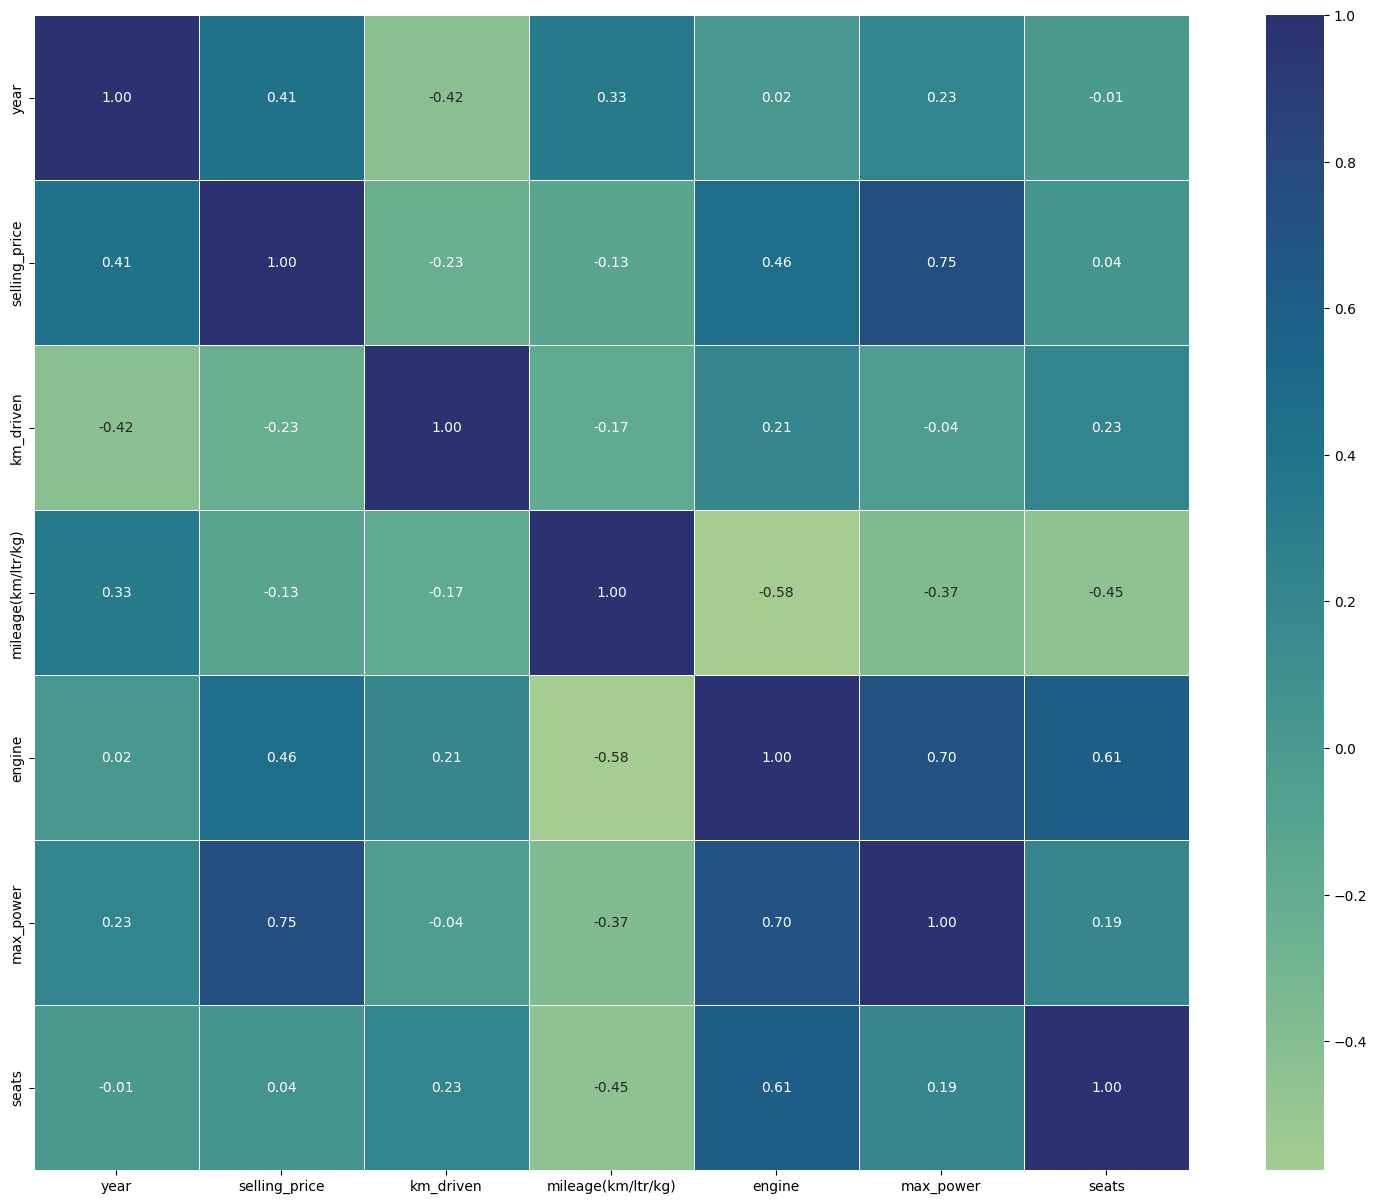

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cdf.corr(), annot=True, fmt=".2f", linewidth=0.5, cmap="crest", square=True)

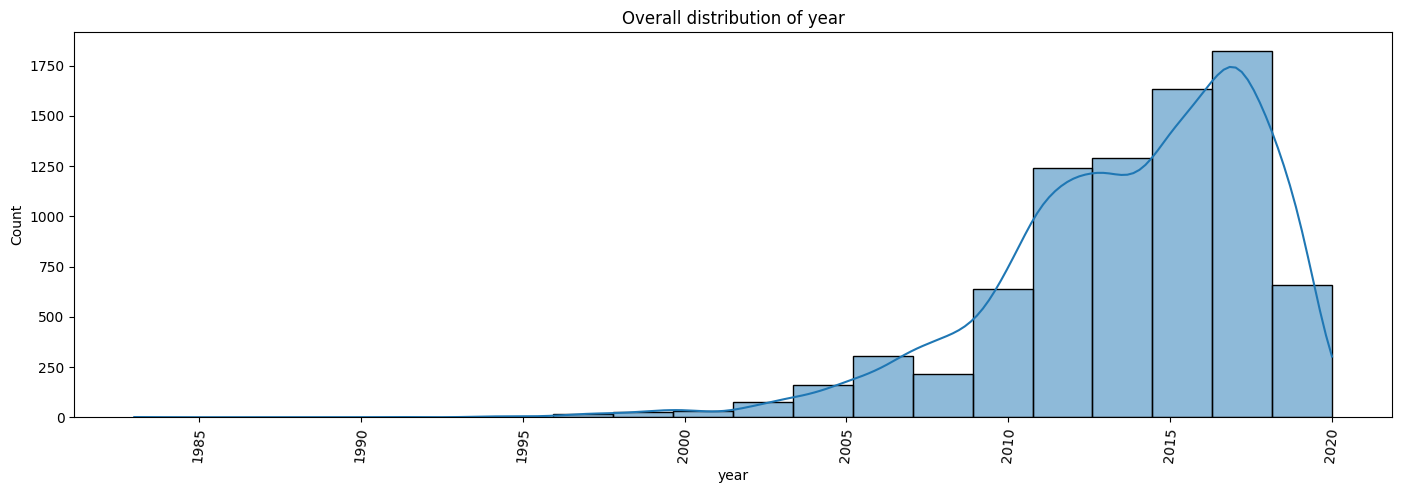

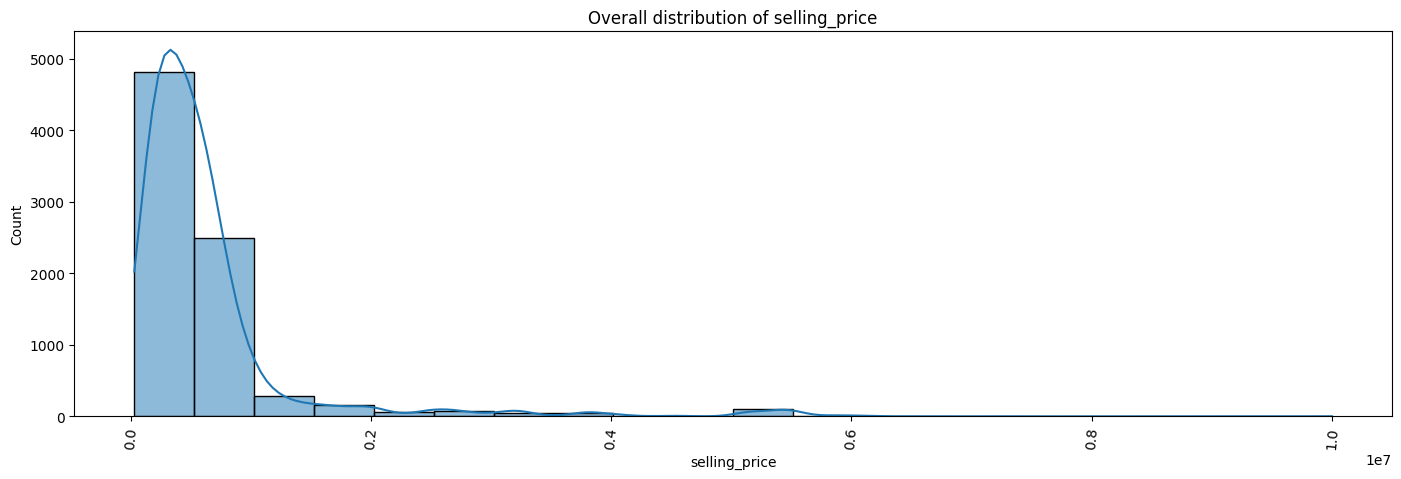

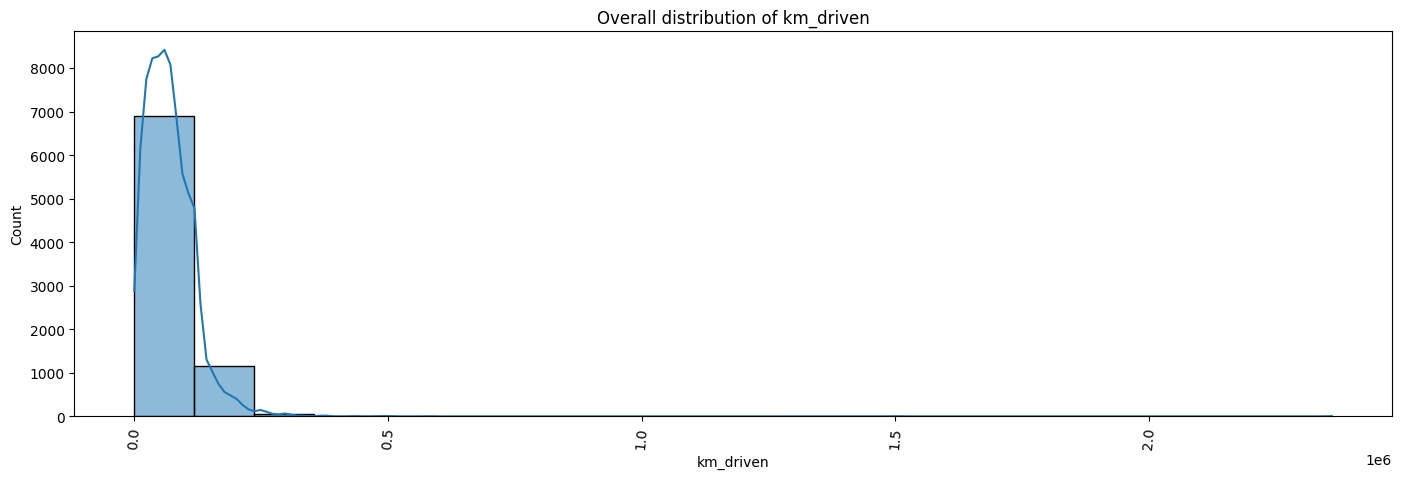

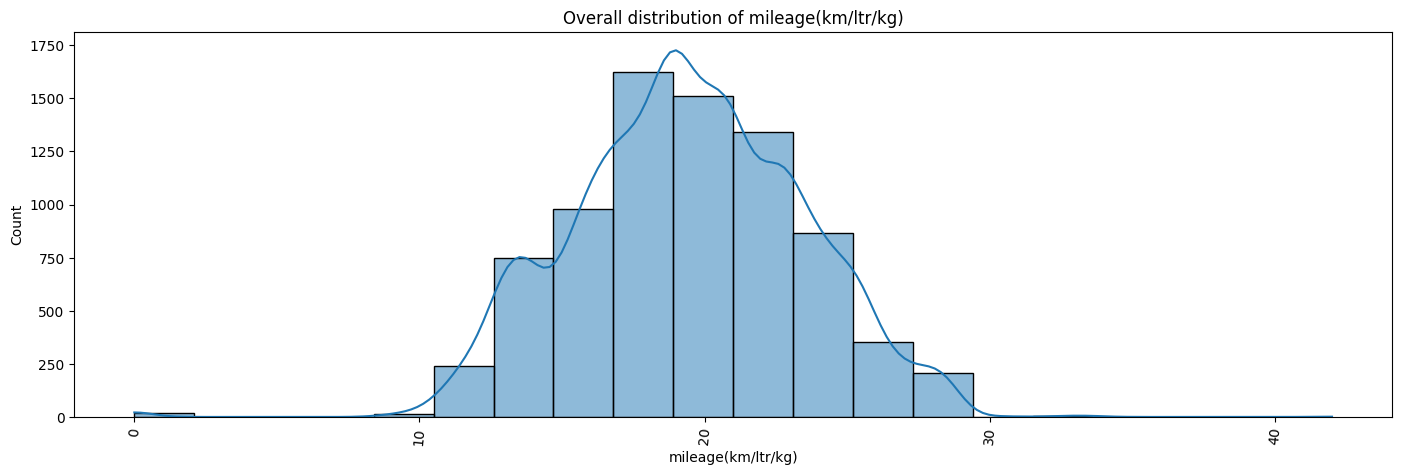

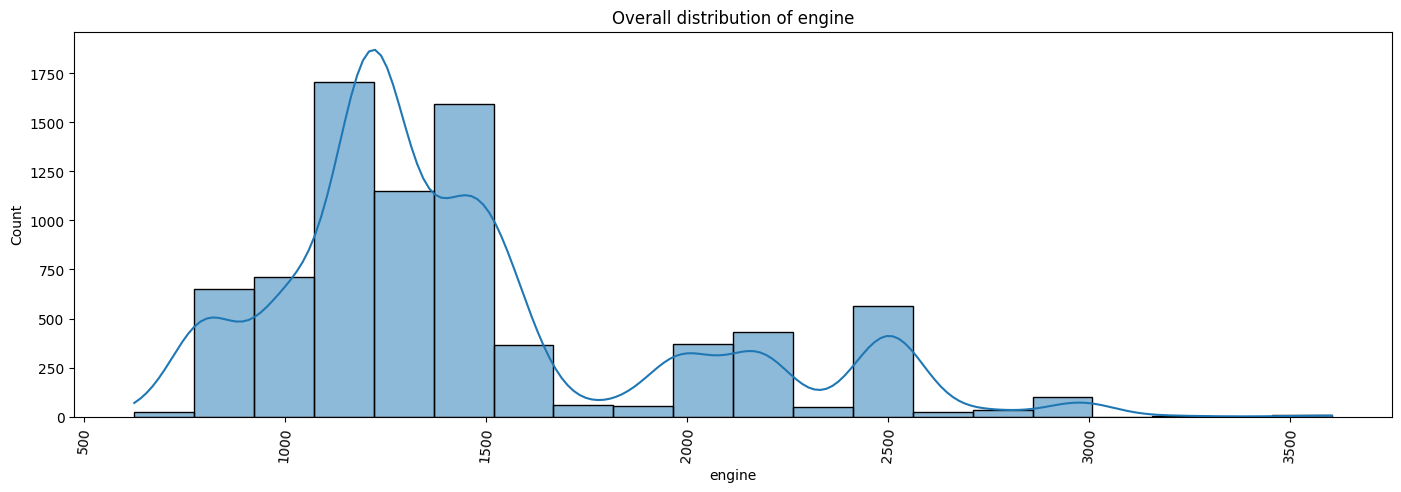

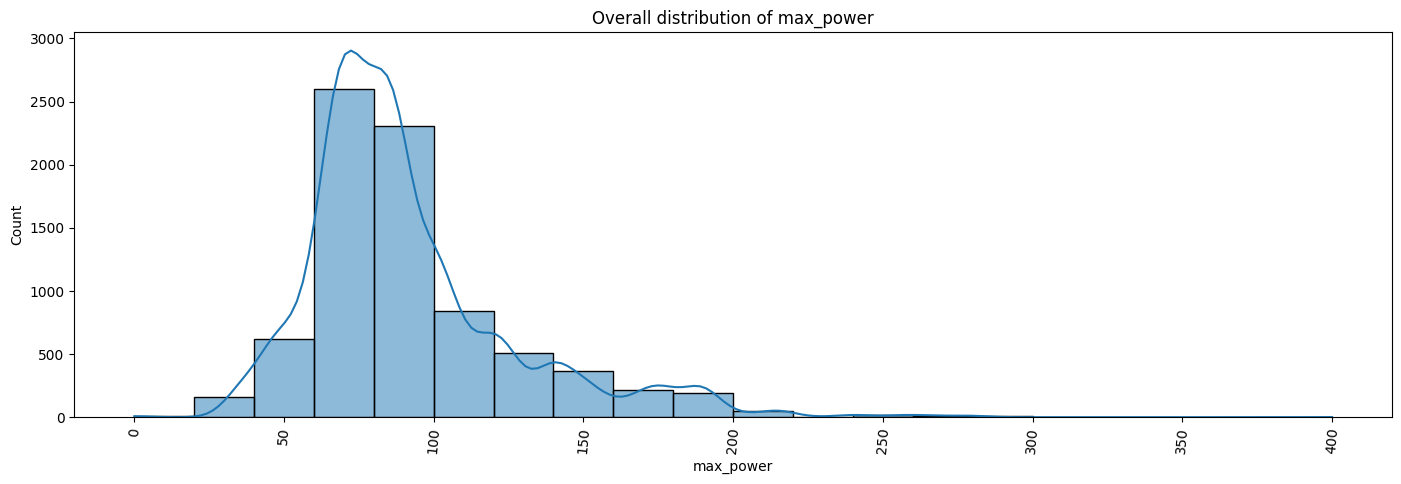

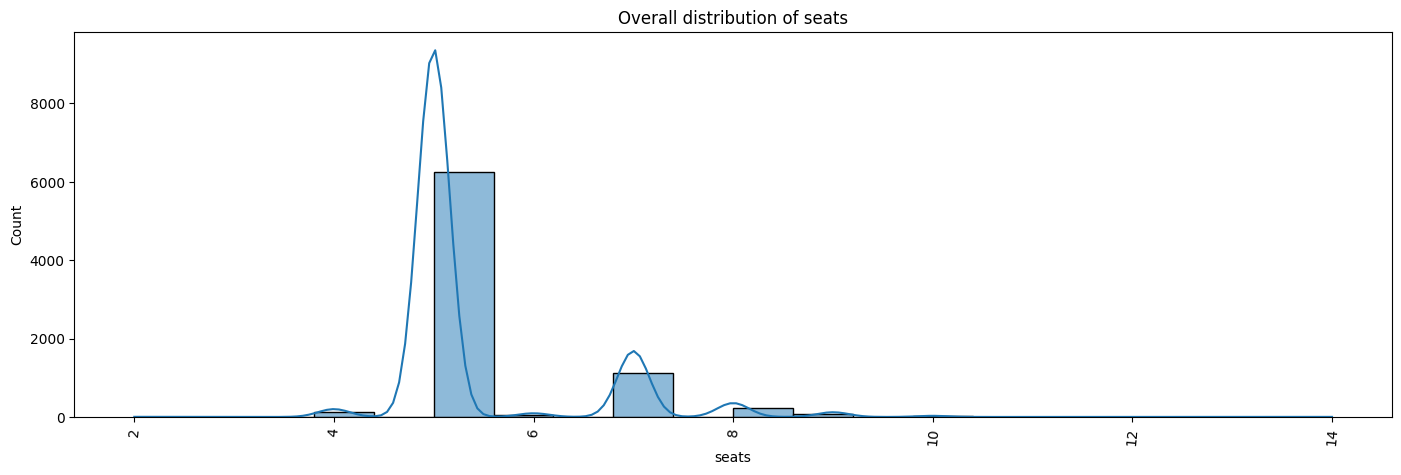

In [ ]:
categorical_cols = cdf.columns.tolist()
for feature in categorical_cols:
    plt.figure(figsize=(17, 5))
    sns.histplot(cdf[feature], bins=20, kde=True)

    plt.title(f"Overall distribution of {feature}")
    plt.xticks(rotation=85)
    plt.show()

### **DEALING WITH NULL VALUES:**

In [ ]:
#Copy to check missing values
cdf2=df.copy()
cdf2.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

In [ ]:
#missing value input
impute = SimpleImputer(missing_values=np.nan, strategy='median')
df['mileage(km/ltr/kg)'] = impute.fit_transform(df[['mileage(km/ltr/kg)']])




impute = SimpleImputer(missing_values=np.nan, strategy='median')
df['engine'] = impute.fit_transform(df[['engine']])




impute = SimpleImputer(missing_values=np.nan, strategy='median')
df['max_power'] = impute.fit_transform(df[['max_power']])




impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df['seats'] = impute.fit_transform(df[['seats']])



In [ ]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  8128 non-null   float64
 9   engine              8128 non-null   float64
 10  max_power           8128 non-null   float64
 11  seats               8128 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 762.1+ KB


### **DEALING WITH DUPLICATE VALUES:**

In [ ]:
cdf3=df.copy()

total_duplicates = cdf3.duplicated().sum()

print(f"Total number of duplicate rows: {total_duplicates}")

Total number of duplicate rows: 1202


In [ ]:
df.drop_duplicates(inplace = True)

total_duplicates = df.duplicated().sum()

print(f"Total number of duplicate rows: {total_duplicates}")

Total number of duplicate rows: 0


### **ENCODING:**

In [ ]:
df['transmission'] = df['transmission'].map({'Manual': 1, 'Automatic': 2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   int64  
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6926 non-null   float64
 9   engine              6926 non-null   float64
 10  max_power           6926 non-null   float64
 11  seats               6926 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 703.4+ KB


In [ ]:
df.head(50)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,1,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,1,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,1,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,1,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,1,First Owner,16.10,1298.0,88.20,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,1,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,1,First Owner,17.30,1061.0,57.50,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,1,Second Owner,16.10,796.0,37.00,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,1,First Owner,23.59,1364.0,67.10,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,1,First Owner,20.00,1399.0,68.10,5.0


### **MAKING A COPY OF THE ACTUAL FATAFRAME WITH ONLY NUMERICAL VALUES:**

In [ ]:
csv=df.copy()
drp=['name','fuel','seller_type','owner']
csv.drop(drp,axis=1,inplace=True)
csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                6926 non-null   int64  
 1   selling_price       6926 non-null   int64  
 2   km_driven           6926 non-null   int64  
 3   transmission        6926 non-null   int64  
 4   mileage(km/ltr/kg)  6926 non-null   float64
 5   engine              6926 non-null   float64
 6   max_power           6926 non-null   float64
 7   seats               6926 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 487.0 KB


### **CHECKING IMBALANCED DATASET WITH PLOT:**

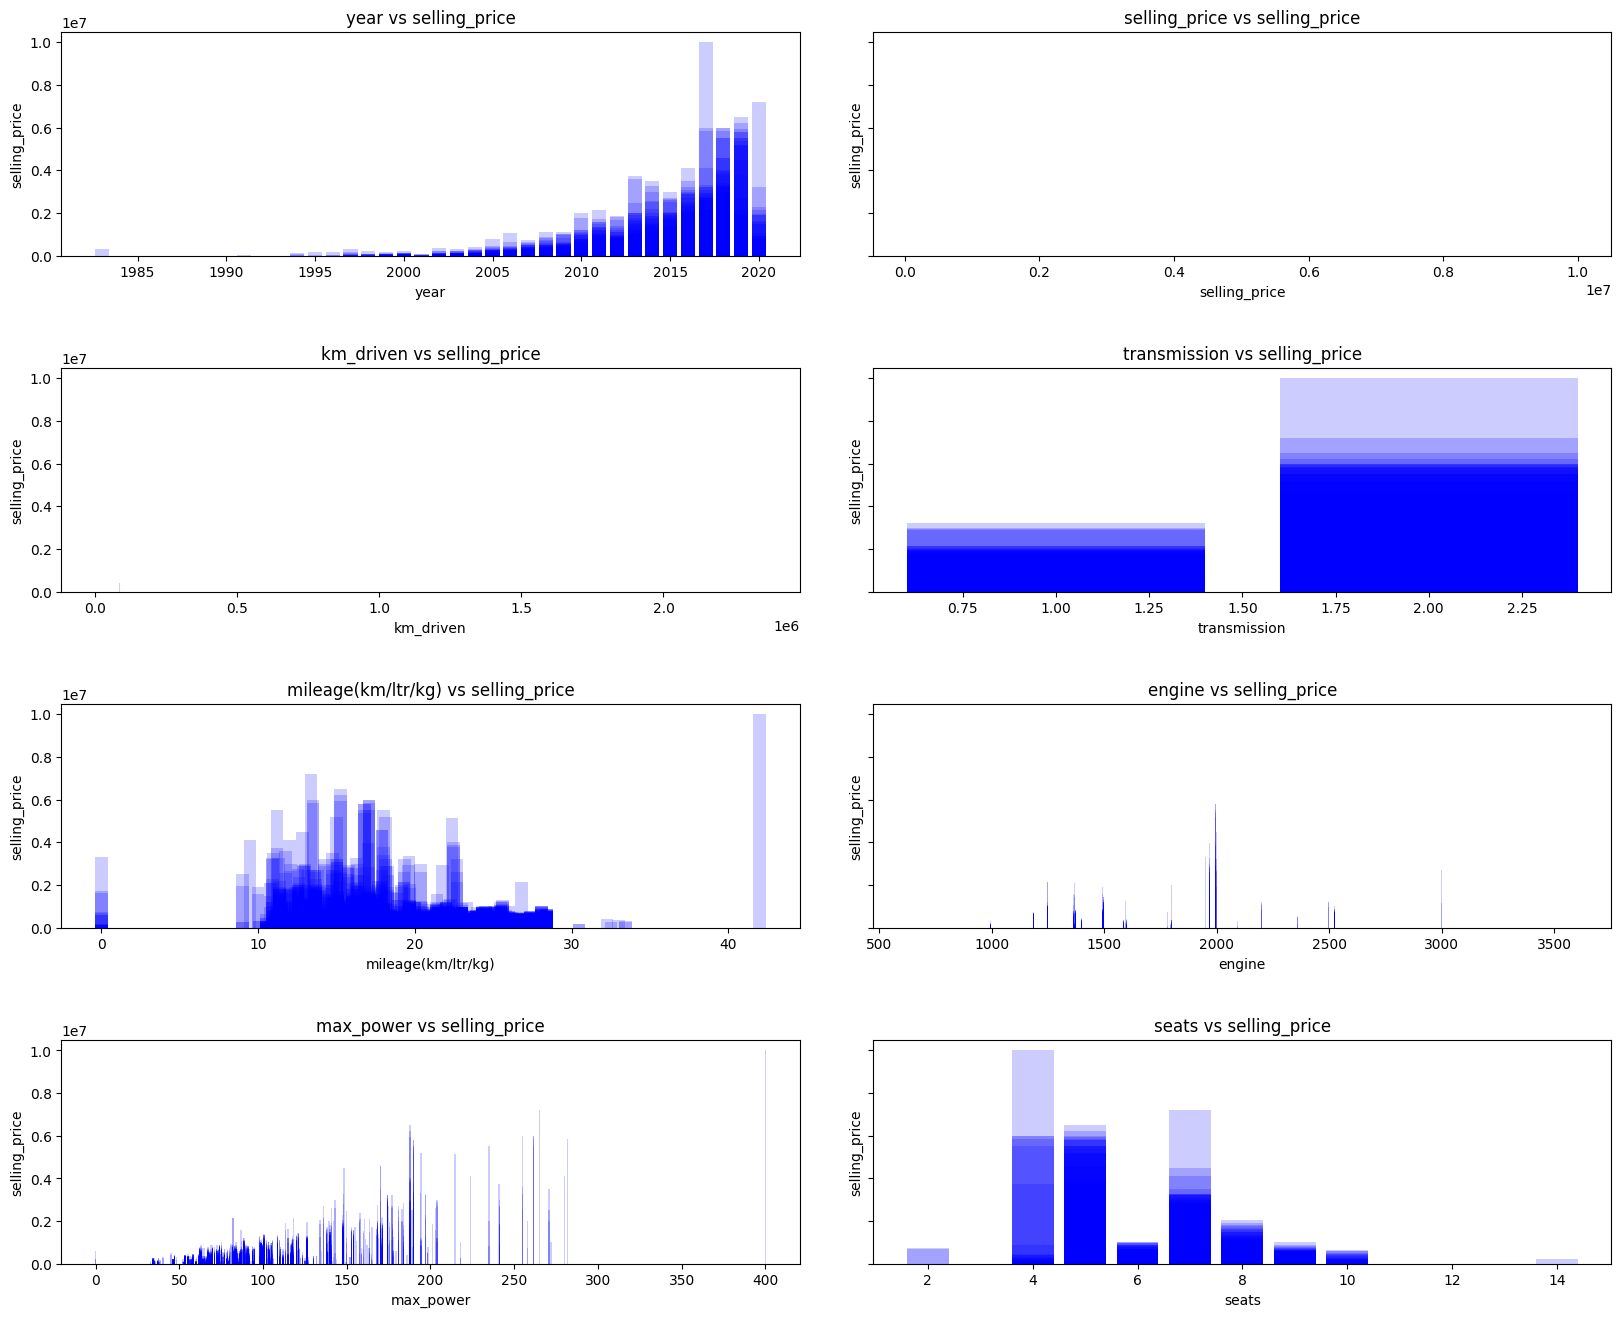

In [ ]:
columns_to_plot = [0, 1, 2, 3, 4, 5, 6, 7]
target = 'selling_price'

figure, axs = plt.subplots(len(columns_to_plot) // 2 + len(columns_to_plot) %
                        2, 2, figsize=(20, len(columns_to_plot) * 2), sharey=True, squeeze=True)

for i, column in enumerate(columns_to_plot):
    axs[i // 2, i % 2].bar(csv.iloc[:, column], csv[target], color='Blue', alpha=0.2)
    axs[i // 2, i % 2].set_xlabel(csv.columns[column])
    axs[i // 2, i % 2].set_ylabel(target)
    axs[i // 2, i % 2].set_title(f'{csv.columns[column]} vs {target}')

figure.subplots_adjust(wspace=0.1, hspace=0.5)

plt.show()

### **SCALING:**

In [ ]:
scaler = StandardScaler()

batch_size = 500

for i in range(0, len(csv), batch_size):
    scaler.partial_fit(csv[i:i+batch_size])

X_scaled = scaler.transform(csv)

X_scaled

array([[ 0.14215322, -0.12943403,  1.22535676, ..., -0.36427469,
        -0.43300214, -0.43369973],
       [ 0.14215322, -0.28336027,  0.78836783, ...,  0.14908097,
         0.50987727, -0.43369973],
       [-1.81959662, -0.69126479,  1.13110424, ...,  0.14702755,
        -0.3052407 , -0.43369973],
       ...,
       [-0.10306551, -0.37956416,  0.61699963, ..., -0.46899924,
        -0.15032996, -0.43369973],
       [-1.57437789, -0.73551859,  0.77123101, ...,  0.13881386,
         0.7168508 , -0.43369973],
       [-1.08394043, -0.26027133,  0.78836783, ..., -0.36427469,
        -0.43619617, -0.43369973]])

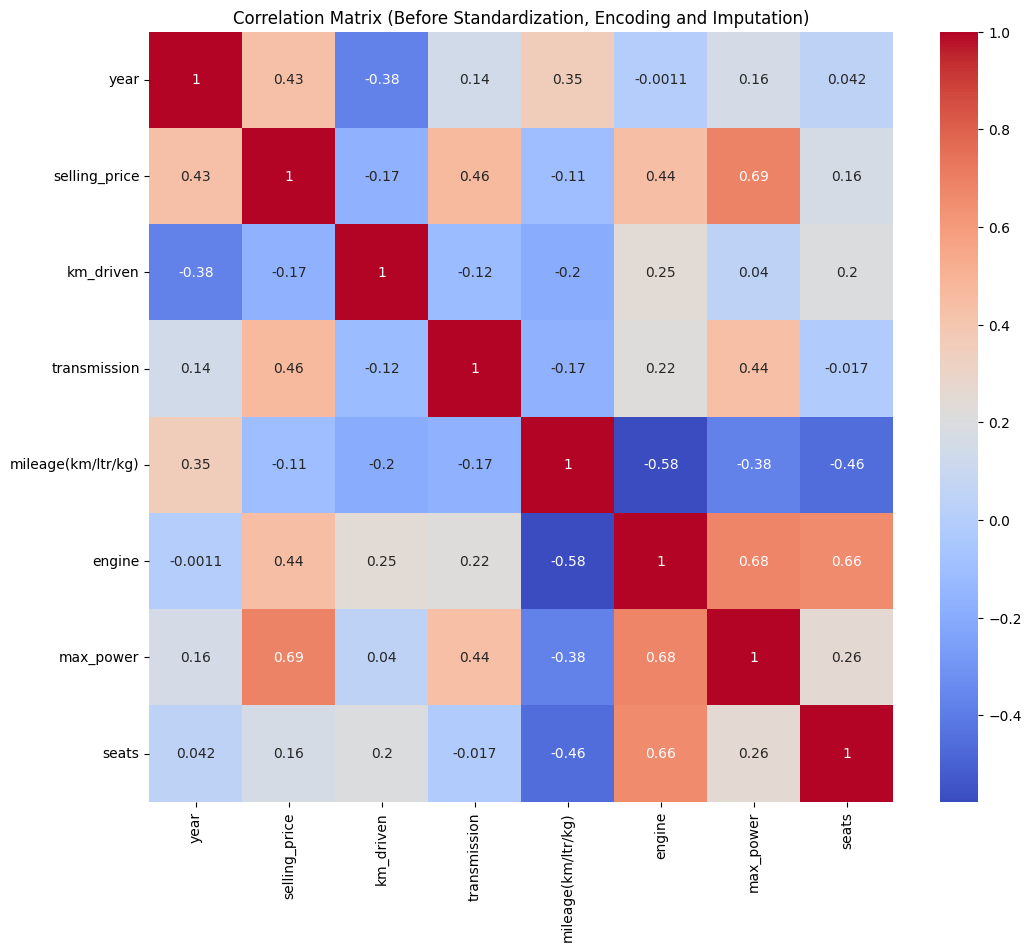

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=csv.columns)
numeric_columns = csv.select_dtypes(include=['int64', 'float64']).columns
housing_numeric = csv[numeric_columns]

corr_before = csv.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_before, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Before Standardization, Encoding and Imputation)')
plt.show()


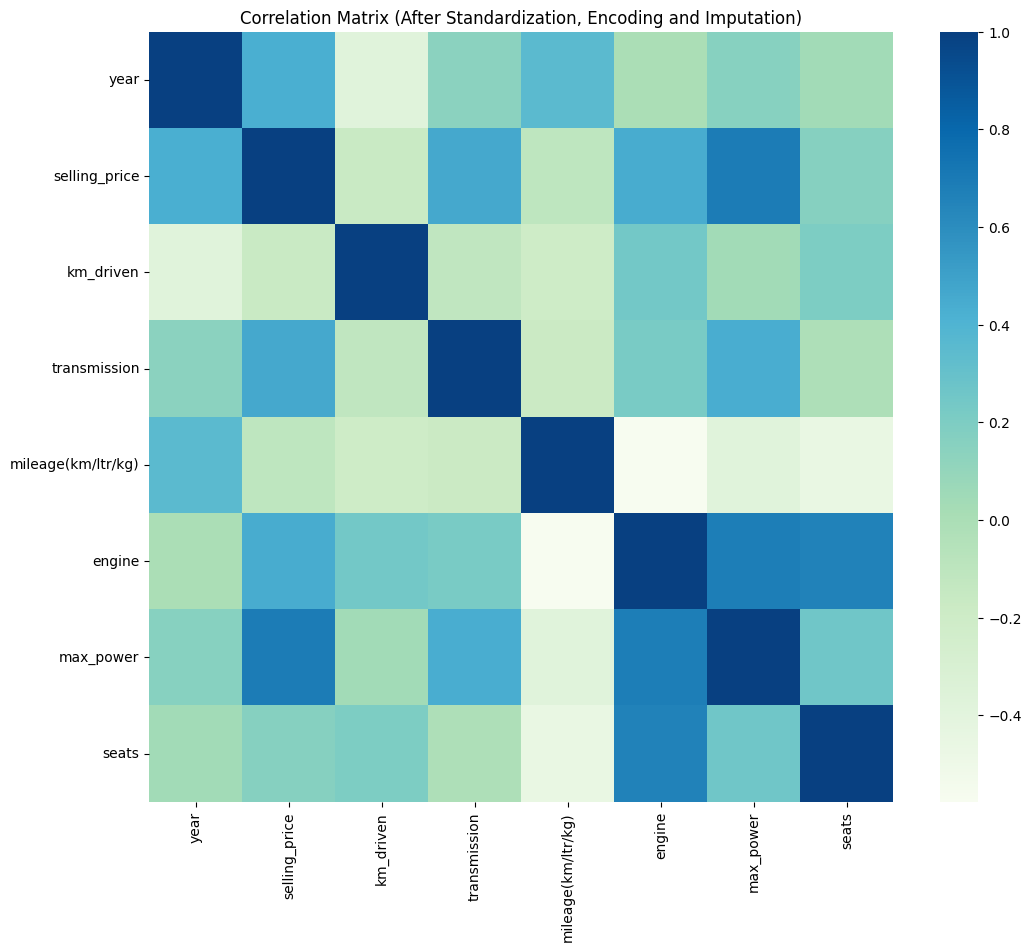

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=csv.columns)

corr_after = X_scaled_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_after, cmap='GnBu')
plt.title('Correlation Matrix (After Standardization, Encoding and Imputation)')
plt.show()


In [ ]:
X = X_scaled
y = csv['selling_price'].to_numpy()

### **SPLITTING:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print(" ")

print("Total number of samples:", len(X_scaled))
print("Number of samples in the training set:", len(X_train))
print("Number of samples in the testing set:", len(X_test))
print("Sum of samples in train and test:", len(X_train) + len(X_test))

test_size_example = len(X_test) / len(X_scaled)
print("Test size proportion:", test_size_example)

print('''
Checking if train and test split is successful
''')

print("Difference:", np.abs(test_size_example - 0.3))

X_train shape: (4848, 8)
X_test shape: (2078, 8)
y_train shape: (4848,)
y_test shape: (2078,)
 
Total number of samples: 6926
Number of samples in the training set: 4848
Number of samples in the testing set: 2078
Sum of samples in train and test: 6926
Test size proportion: 0.3000288766965059

Checking if train and test split is successful

Difference: 2.8876696505919508e-05


### **CHEACKING FOR OVERLAP:**

In [ ]:
X = pd.DataFrame(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

if any(np.intersect1d(X_train.index, X_test.index)):
    print("The train and test data is mixed.")
else:
    print("The train and test data is not mixed.")

The train and test data is not mixed.


### **TEST MODELS:**

### 1.Linear Regression:

In [ ]:
linreg = LinearRegression().fit(X_train, y_train)
residuals = y_train - linreg.predict(X_train)
outlier_threshold = 3*np.std(residuals)
outliers = np.abs(residuals) > outlier_threshold

linreg_score = 0

if np.all(outliers):
    print("All samples are outliers, cannot fit a linear regression model")
else:
    X_train_cleaned, y_train_cleaned = X_train[~outliers], y_train[~outliers]

    linreg_cleaned = LinearRegression().fit(X_train_cleaned, y_train_cleaned)

    y_pred_cleaned = linreg_cleaned.predict(X_test)

    mse_cleaned = mean_squared_error(y_test, y_pred_cleaned)
    rmse_cleaned = np.sqrt(mse_cleaned)
    mae = mean_absolute_error(y_test, y_pred_cleaned)

    r2_score_cleaned = r2_score(y_test, y_pred_cleaned) * 100

    linreg_score = r2_score_cleaned
    linreg_mae = mae

    print(f"Mean Squared Error: {mse_cleaned:.2f}")
    print(f"Root Mean Squared Error: {rmse_cleaned:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(" ")
    print(f"R^2 Score: {r2_score_cleaned:.6f}%")

Mean Squared Error: 0.00
Root Mean Squared Error: 0.00
Mean Absolute Error: 0.00
 
R^2 Score: 100.000000%


In [ ]:
train_accuracy = linreg_cleaned.score(X_train_cleaned, y_train_cleaned)

test_accuracy = linreg_cleaned.score(X_test, y_test)

print('Training accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)

Training accuracy: 1.0
Test accuracy: 1.0


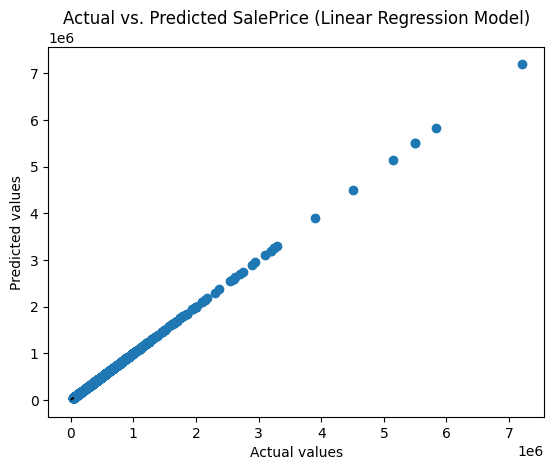

In [ ]:
plt.scatter(y_test, y_pred_cleaned)
plt.plot([0, 50000], [0, 50000], '--k')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs. Predicted SalePrice (Linear Regression Model)')
plt.show()

### 2. DECISION TREE REGRESSOR:

In [ ]:
X = X_scaled
y = csv['selling_price'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

decisionTreeRegressor = DecisionTreeRegressor()

decisionTreeRegressor.fit(X_train, y_train)

y_pred = decisionTreeRegressor.predict(X_test)



In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

r2 = (decisionTreeRegressor.score(X_test,y_test))*100

dectree_score = r2
dectree_mae = mae

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(" ")
print(f"R^2 Score: {r2:.6f}%")

Mean Squared Error: 522626863.82
Root Mean Squared Error: 22861.03
Mean Absolute Error: 1414.62
 
R^2 Score: 99.774215%


In [ ]:
train_accuracy = decisionTreeRegressor.score(X_train, y_train)
test_accuracy = decisionTreeRegressor.score(X_test, y_test)

print('Training accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy) #as we got 1 as result and it is completely fine because the limit is 5-10%

Training accuracy: 1.0
Test accuracy: 0.9977421543189091


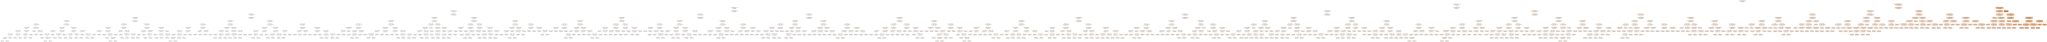

In [ ]:
dot_data = export_graphviz(decisionTreeRegressor, out_file=None,
                           feature_names=list(csv.columns),
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)

display(graph)

### 3. SUPPORT VECTOR MACHINE (SVM):

In [ ]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
svm_model = SVR(kernel='rbf', C=190000, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)


accuracy_percent = r2 * 100
svm_score = accuracy_percent
print("Accuracy:", accuracy_percent)

Accuracy: 82.30378395078937


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)*100

svm_score = r2
svm_mae = mae

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(" ")
print(f"R^2 score: {r2:.2f}%")

Mean Squared Error: 40961691814.25
Root Mean Squared Error: 202389.95
Mean Absolute Error: 17417.48
 
R^2 score: 82.30%


### **COMPARATIVE ANALYSIS:**

In [ ]:
train_accuracy = svm_model.score(X_train_scaled, y_train)
test_accuracy = svm_model.score(X_test_scaled, y_test)

print('Training accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)

Training accuracy: 0.8070372329669193
Test accuracy: 0.8230378395078937


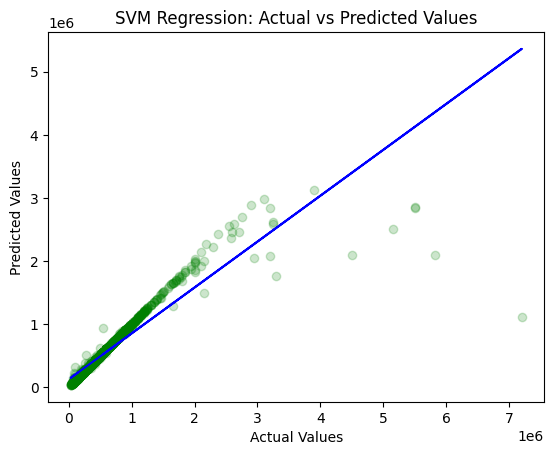

In [ ]:
plt.scatter(y_test, y_pred, color='green', alpha=0.2)

coefficients = np.polyfit(y_test, y_pred, 1)
polynomial = np.poly1d(coefficients)
plt.plot(y_test, polynomial(y_test), color='blue')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVM Regression: Actual vs Predicted Values')
plt.show()

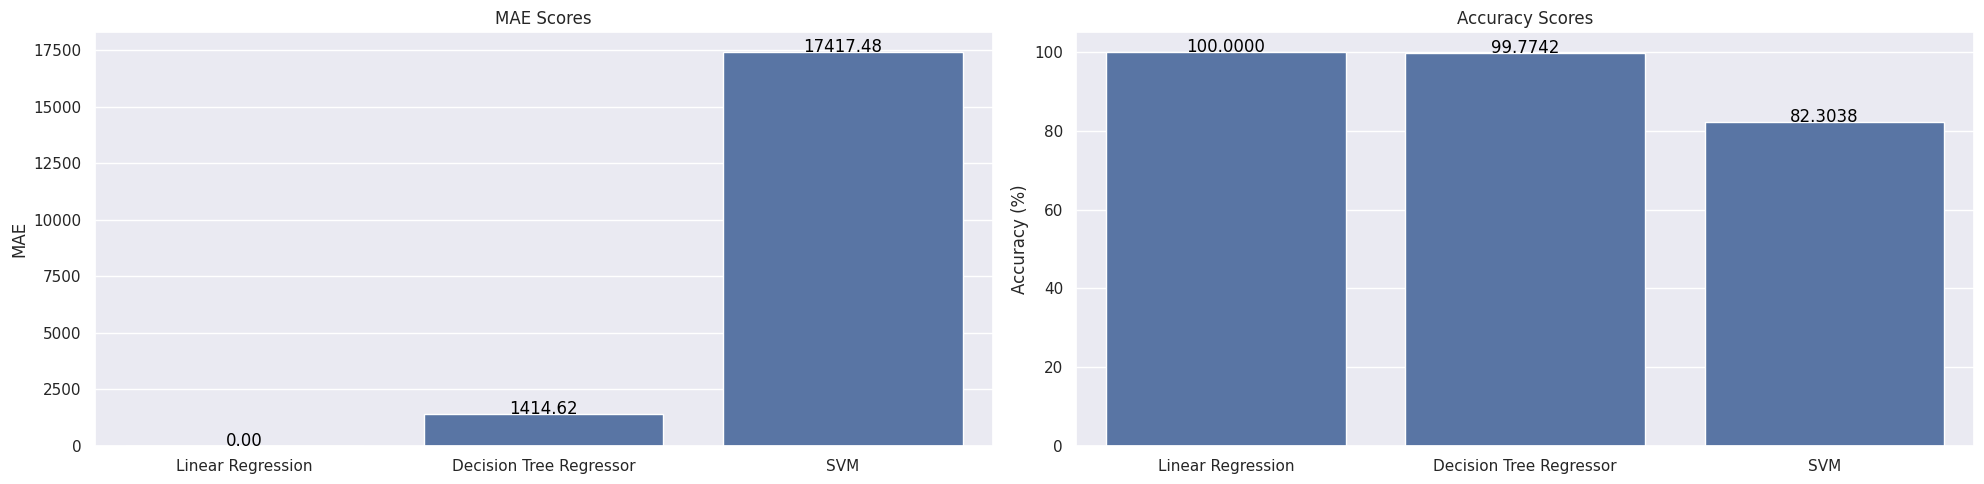

In [ ]:
models = ['Linear Regression','Decision Tree Regressor', 'SVM']
mae_scores = [linreg_mae, dectree_mae, svm_mae]
accuracy_scores = [linreg_score, dectree_score, svm_score]

sns.set(style="darkgrid")

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

sns.barplot(x=models, y=mae_scores, ax=axs[0])
axs[0].set_title('MAE Scores')
axs[0].set_ylabel('MAE')

for i, v in enumerate(mae_scores):
    axs[0].text(i, v, f"{v:.2f}", color='black', ha="center")


sns.barplot(x=models, y=accuracy_scores, ax=axs[1])
axs[1].set_title('Accuracy Scores')
axs[1].set_ylabel('Accuracy (%)')

for i, v in enumerate(accuracy_scores):
    axs[1].text(i, v, f"{v:.4f}", color='black', ha="center")

fig.tight_layout()
plt.show()

### **OUTPUT:**

In [ ]:
print(f'''The models prediction accuracy are as follows:

Linear Regression: {linreg_score:.4f}%
Decision Tree Regressor: {dectree_score:.4f}%
Support Machine Vector: {svm_score:.4f}%
''')

The models prediction accuracy are as follows:

Linear Regression: 100.0000%
Decision Tree Regressor: 99.7742%
Support Machine Vector: 82.3038%

